In [1]:
import re
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
from nltk.tokenize import word_tokenize
import numpy as np

torch.manual_seed(42)

/Users/art/anaconda3/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/art/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
[nltk_data] Downloading package punkt to /Users/art/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/art/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
with open('article.txt','r', encoding="utf-8") as f:
    text = f.read()

In [3]:
paragraphs = [p.strip() for p in text.split('\n') if len(p.strip()) > 80]
len(paragraphs)

66

In [4]:
def tokenize(p):
    tokens = word_tokenize(p.lower())
    return [t for t in tokens if t.isalpha()]

In [5]:
tokenized_paragraphs = [tokenize(p) for p in paragraphs]

In [6]:
all_tokens = [t for toks in tokenized_paragraphs for t in toks]

In [7]:
# all_tokens

In [8]:
vocab_counter = Counter(all_tokens)

In [9]:
# vocab_counter

In [10]:
vocab = ["<PAD>", "<UNK>"] + [w for w,c in vocab_counter.most_common()]
word2idx = {w:i for i,w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
VOCAB_SIZE
# word2idx
VOCAB_SIZE

1368

In [11]:
length = np.array([len(toks) for toks in tokenized_paragraphs])

length.min()

15

In [12]:
length.max()

166

In [13]:
length.mean()

77.83333333333333

In [14]:
np.percentile(length,90)

122.0

In [15]:
np.percentile(length,95)

139.5

In [16]:
np.percentile(length,99)

159.49999999999994

In [17]:
import matplotlib.pyplot as plt

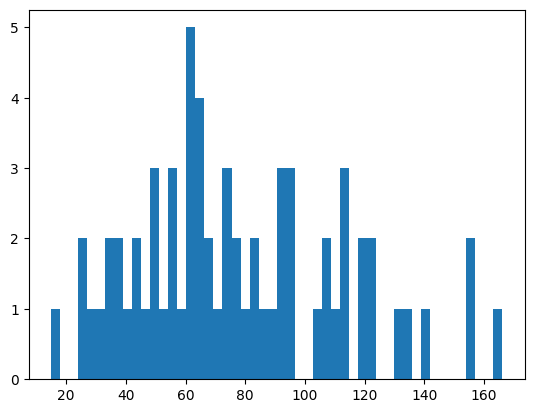

In [18]:
plt.hist(length, bins=50);

In [19]:
MAX_LEN = 140

def encode(tokens, max_len=MAX_LEN):
    idx = [word2idx.get(t,1) for t in tokens]
    if len(idx) >= max_len:
        return idx[:max_len]
    return idx + [0] *(max_len- len(idx))

In [20]:
def has_quote(p):
    return 'quote' if ('\u201c' in p or '\u201d' in p) else 'no_quote'


In [21]:
raw_labels = [has_quote(p) for p in paragraphs]
# y = np.array(list(map(lambda x : 0 if x=='no_quote' else 1, raw_labels)))
# y
encoder = LabelEncoder()
y = encoder.fit_transform(raw_labels)   

In [22]:
X_sequences = [encode(toks) for toks in tokenized_paragraphs]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_sequences, y, test_size=0.3, random_state=42)

In [24]:
class ParagraphDataset(Dataset):
    def __init__(self, sequenses, labels):
        self.X = torch.tensor(sequenses, dtype=torch.long)
        self.y = torch.tensor(labels, dtype=torch.long)
        
    def __len__(self):
        return len(self.y)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [25]:
len(X_train)

46

In [26]:
train_ds = ParagraphDataset(X_train, y_train)
test_ds = ParagraphDataset(X_test,y_test)

In [27]:
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)

In [28]:
EMBED_DIM = 50

In [29]:
NUM_CLASSES = 2

In [30]:
class DenseClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size,embed_dim, padding_idx=0)
        self.fc1 = nn.Linear(embed_dim, 32)
        self.fc2 = nn.Linear(32, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        embedded = self.embedding(x)
        pooled = embedded.mean(dim=1)
        h = self.relu(self.fc1(pooled))
        return self.fc2(self.dropout(h))

In [31]:
class CNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, num_filter=32, kernel_sizes=(2,3,4) ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([ nn.Conv1d(embed_dim, num_filter, kernel_size=k) for k in kernel_sizes])
        self.fc = nn.Linear(num_filter* len(kernel_sizes), num_classes)
        self.dropout = nn.Dropout(0.3) 
    
    def forward(self, x):
        embedded = self.embedding(x).permute(0,2,1)
        conv_outs = []
        for conv in self.convs:
            c = torch.relu(conv(embedded))
            pooled = torch.max(c, dim=2)[0]
            conv_outs.append(pooled)
        combined = torch.cat(conv_outs, dim=1)
        return self.fc(self.dropout(combined))

In [32]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, hidden_dim=32 ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim*2, num_classes)
        self.dropout = nn.Dropout(0.3)
        
    def forward(self,x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        final_hidden = torch.cat((hidden[0], hidden[1]), dim=1)
        return self.fc(self.dropout(final_hidden))

In [33]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, max_len=MAX_LEN, num_heads=2, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_encoding = nn.Parameter(torch.randn(1,max_len,embed_dim)*0.01)
        encoder_layer  = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, batch_first=True, dropout=0.3
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(embed_dim, num_classes)
        
    def forward(self,x):
        embedded = self.embedding(x) + self.pos_encoding[: , :x.size(1), :]
        attended = self.transformer(embedded)
        pooled = attended.mean(dim=1)
        return self.fc(pooled)

In [34]:
def train_and_evaluate(model, name, epochs=15, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
 
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
 
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.tolist())
            all_labels.extend(y_batch.tolist())
 
    acc = accuracy_score(all_labels, all_preds)
    print(f"\n=== {name} ===")
    print(f"Test accuracy: {acc:.3f}")
    print(classification_report(all_labels, all_preds, target_names=encoder.classes_, zero_division=0))
    return acc

In [35]:
results = {}
 
results['Dense'] = train_and_evaluate(
    DenseClassifier(VOCAB_SIZE, EMBED_DIM, NUM_CLASSES), "Dense (avg-pooled embeddings)"
)
results['CNN'] = train_and_evaluate(
    CNNClassifier(VOCAB_SIZE, EMBED_DIM, NUM_CLASSES), "CNN (sliding filters)"
)
results['LSTM'] = train_and_evaluate(
    LSTMClassifier(VOCAB_SIZE, EMBED_DIM, NUM_CLASSES), "LSTM (bidirectional, sequential)"
)
results['Transformer'] = train_and_evaluate(
    TransformerClassifier(VOCAB_SIZE, EMBED_DIM, NUM_CLASSES), "Transformer (self-attention)"
)
 
print("\n=== Summary: all four architectures, same data, same task ===")
for name, acc in results.items():
    print(f"{name:12s}: {acc:.3f}")


=== Dense (avg-pooled embeddings) ===
Test accuracy: 0.600
              precision    recall  f1-score   support

    no_quote       0.00      0.00      0.00         8
       quote       0.60      1.00      0.75        12

    accuracy                           0.60        20
   macro avg       0.30      0.50      0.38        20
weighted avg       0.36      0.60      0.45        20


=== CNN (sliding filters) ===
Test accuracy: 0.600
              precision    recall  f1-score   support

    no_quote       0.00      0.00      0.00         8
       quote       0.60      1.00      0.75        12

    accuracy                           0.60        20
   macro avg       0.30      0.50      0.38        20
weighted avg       0.36      0.60      0.45        20


=== LSTM (bidirectional, sequential) ===
Test accuracy: 0.550
              precision    recall  f1-score   support

    no_quote       0.33      0.12      0.18         8
       quote       0.59      0.83      0.69        12

    acc